Pittsburgh Foodie Neighborhood Analysis- Pier

In [ ]:

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load data
df = pd.read_csv("food_facilities.csv")
hoods = gpd.read_file("neighborhoods.geojson")

# Filter to foodie categories and filter out non food facilities
foodie_keywords = ["Restaurant", "Bakery", "Social Club-Bar Only", "Supermarket", "Food Processor"]
mask = df["description"].str.contains("|".join(foodie_keywords), na=False)
foodie = df[mask].copy()

# Filter to active Pittsburgh facilities with valid coordinates
foodie = foodie[foodie["bus_cl_date"].isna()]
foodie = foodie.dropna(subset=["x", "y"])

# Assign each restaurant to its neighborhood using the point in polygon spatial join
foodie["geometry"] = foodie.apply(lambda r: Point(r["x"], r["y"]), axis=1)
foodie_gdf = gpd.GeoDataFrame(foodie, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:2272")
hoods = hoods.to_crs("EPSG:2272")
hoods["area_sqmi"] = hoods.geometry.area / 27_878_400

joined = gpd.sjoin(foodie_gdf, hoods[["hood", "area_sqmi", "geometry"]], how="left", predicate="within")

# Count and normalize data for score 0-100
counts = joined.groupby("hood").size().reset_index(name="restaurant_count")
result = hoods[["hood", "area_sqmi"]].merge(counts, on="hood", how="left").fillna(0)
result["restaurants_per_sqmi"] = result["restaurant_count"] / result["area_sqmi"]
result["score"] = (result["restaurants_per_sqmi"] / result["restaurants_per_sqmi"].max() * 100).round(1)

#view results
result.sort_values("score", ascending=False).head(20)

,hood,area_sqmi,restaurant_count,restaurants_per_sqmi,score
43,Central Business District,0.538849,558.0,1035.541122,100.0
29,North Shore,0.297023,221.0,744.050017,71.9
46,Central Oakland,0.280047,153.0,546.336931,52.8
81,Strip District,0.608240,232.0,381.428481,36.8
88,South Side Flats,0.924315,294.0,318.073428,30.7
66,South Shore,0.230745,67.0,290.364073,28.0
8,North Oakland,0.496999,141.0,283.702928,27.4
44,East Allegheny,0.234916,66.0,280.951917,27.1
52,Bloomfield,0.701931,170.0,242.189051,23.4
22,Bluff,0.325261,69.0,212.137146,20.5


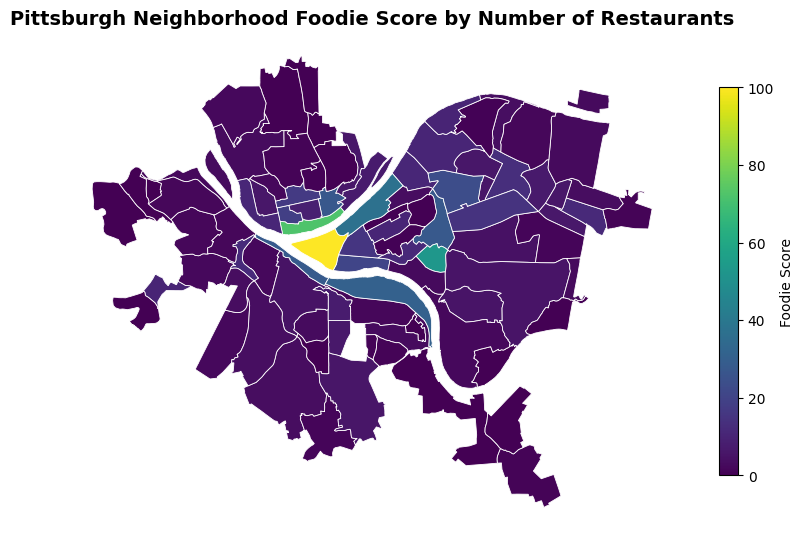

In [ ]:
# Map of Foodie Scores
import matplotlib.pyplot as plt

# Merge scores back onto the geometry
hoods_scored = hoods.merge(result[["hood", "score"]], on="hood", how="left")

# Plot
fig, ax = plt.subplots(figsize=(8, 10))

hoods_scored.plot(
    column="score",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"label": "Foodie Score", "shrink": 0.4},
)

ax.set_title("Pittsburgh Neighborhood Foodie Score by Number of Restaurants", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

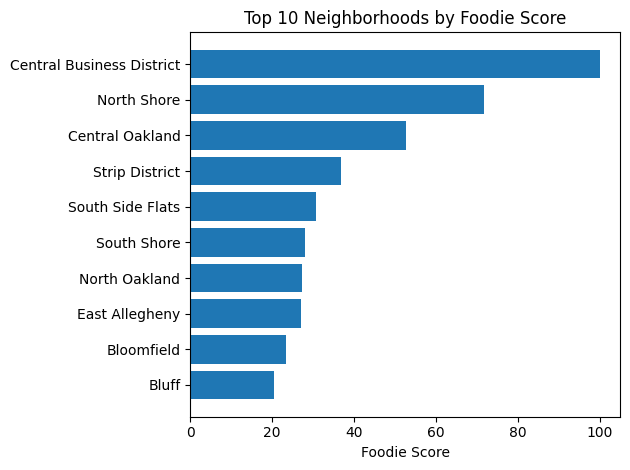

In [ ]:
# bar chart of top 10 neighborhoods by Foodie Score
import matplotlib.pyplot as plt
top10 = result.sort_values("score", ascending=False).head(10)
plt.barh(top10["hood"], top10["score"])
plt.gca().invert_yaxis()
plt.xlabel("Foodie Score")
plt.title("Top 10 Neighborhoods by Foodie Score")
plt.tight_layout()
plt.show()